In [ ]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

print("Please upload all 6 CSV files...")
uploaded = files.upload()

Please upload all 6 CSV files...


Saving LearnerOpportunity_Raw(in).csv to LearnerOpportunity_Raw(in).csv
Saving Cognito_Raw2(in).csv to Cognito_Raw2(in).csv
Saving Marketing Campaign Data All Accounts (2023-2024)(Detail1).csv to Marketing Campaign Data All Accounts (2023-2024)(Detail1).csv
Saving CohortRaw(in).csv to CohortRaw(in).csv
Saving Opportunity_Raw(in).csv to Opportunity_Raw(in).csv
Saving Learner_Raw(in).csv to Learner_Raw(in).csv


In [ ]:
# 📥 STEP 2 — Load Datasets
# Use the uploaded filenames
try:
    user_df = pd.read_csv("Learner_Raw(in).csv")
    opp_df = pd.read_csv("Opportunity_Raw(in).csv")
    cohort_df = pd.read_csv("CohortRaw(in).csv")
    marketing_df = pd.read_csv("Marketing Campaign Data All Accounts (2023-2024)(Detail1).csv", encoding='latin-1')
    learner_df = pd.read_csv("LearnerOpportunity_Raw(in).csv")
    cognito_df = pd.read_csv("Cognito_Raw2(in).csv")

    datasets = {
        "User Data": user_df,
        "Opportunity Data": opp_df,
        "Cohort Data": cohort_df,
        "Marketing Data": marketing_df,
        "Learner Opportunity": learner_df,
        "Cognito Data": cognito_df
    }
except UnicodeDecodeError:
    print("UnicodeDecodeError: Could not decode the file using the specified encoding. Please check the file encoding.")

In [ ]:
# 🔍 STEP 3 — Dataset Exploration
print("Dataset Exploration:")
for name, df in datasets.items():
    print(f"===== 📊 {name} =====")
    print("Shape:", df.shape)
    print("\nColumns:", df.columns.tolist())
    print("\nInfo:")
    print(df.info())
    print("\nFirst 5 rows:")
    print(df.head())
    print("="*60)

Dataset Exploration:
===== 📊 User Data =====
Shape: (129259, 5)

Columns: ['learner_id', 'country', 'degree', 'institution', 'major']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129259 entries, 0 to 129258
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   learner_id   129259 non-null  object
 1   country      126984 non-null  object
 2   degree       76566 non-null   object
 3   institution  76186 non-null   object
 4   major        76388 non-null   object
dtypes: object(5)
memory usage: 4.9+ MB
None

First 5 rows:
                                     learner_id     country  \
0  Learner#00004f18-8b86-4fe4-ad7e-6c8d988f5335     Nigeria   
1  Learner#00006478-745f-49bf-b126-02584e830720     Nigeria   
2  Learner#00010567-1336-433c-a941-a612b3d2fbb8       Kenya   
3  Learner#00011c80-0c5c-4601-9696-b3ca787e264f  Bangladesh   
4  Learner#000141a7-4c82-401f-a2e6-dd12b4b26089     Nigeria   

                

In [ ]:
# 📊 STEP 4 — EDA (Missing values, stats, duplicates)
print("EDA:")
for name, df in datasets.items():
    print(f"===== 📊 EDA for {name} =====")
    print("Missing Values:\n", df.isnull().sum())
    print("\nDuplicates:", df.duplicated().sum())
    print("\nBasic Statistics:")
    print(df.describe(include='all'))
    print("="*60)

EDA:
===== 📊 EDA for User Data =====
Missing Values:
 learner_id         0
country         2275
degree         52693
institution    53073
major          52871
dtype: int64

Duplicates: 0

Basic Statistics:
                                          learner_id country  \
count                                         129259  126984   
unique                                        129259     190   
top     Learner#ffd4214b-cdcd-40bc-bec9-b045c3d1ba7b   India   
freq                                               1   33868   

                  degree             institution             major  
count              76566                   76186             76388  
unique                 7                   34563              4501  
top     Graduate Student  Saint Louis University  Computer Science  
freq               31806                    2163              4704  
===== 📊 EDA for Opportunity Data =====
Missing Values:
 opportunity_id         0
opportunity_name       0
category              

In [ ]:

# User Sign-up Trends
if "signup_date" in user_df.columns:
    user_df["signup_date"] = pd.to_datetime(user_df["signup_date"], errors="coerce")
    user_df.groupby(user_df["signup_date"].dt.to_period("M")).size().plot(kind="line", marker="o")
    plt.title("User Sign-ups Over Time")
    plt.ylabel("Number of Sign-ups")
    plt.show()


/tmp/ipython-input-595874779.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  signup_counts = cognito_df.groupby(pd.to_datetime(cognito_df["UserCreateDate"], errors="coerce").dt.to_period("M")).size()


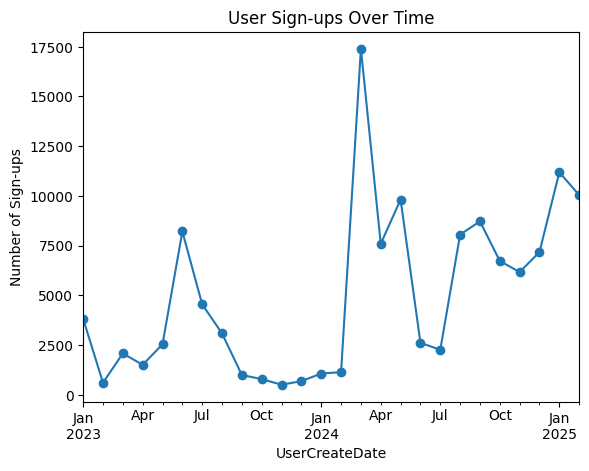

In [ ]:
# Based on the `user_df` DataFrame from the latest notebook state, the column containing user sign-up dates is `UserCreateDate`.
signup_counts = cognito_df.groupby(pd.to_datetime(cognito_df["UserCreateDate"], errors="coerce").dt.to_period("M")).size()
signup_counts.index = signup_counts.index.to_timestamp()
signup_counts.plot(kind="line", marker="o")
plt.title("User Sign-ups Over Time")
plt.ylabel("Number of Sign-ups")
plt.show()

In [ ]:
# Top 10 Opportunities
if "opportunity_id" in learner_df.columns:
    top_opps = learner_df["opportunity_id"].value_counts().head(10).reset_index()
    top_opps.columns = ["opportunity_id", "count"]  # Rename columns

    plt.figure(figsize=(10,6))
    sns.barplot(x="opportunity_id", y="count", data=top_opps, palette="viridis")
    plt.title("Top 10 Opportunities by Participation")
    plt.xlabel("Opportunity ID")
    plt.ylabel("Number of Participants")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


oppurtunities by category (if available)

In [ ]:
if "opportunity_type" in learner_df.columns:
    type_counts = learner_df["opportunity_type"].value_counts()

    plt.figure(figsize=(8,6))
    sns.barplot(x=type_counts.index, y=type_counts.values, palette="pastel")
    plt.title("Opportunities by Type")
    plt.xlabel("Type")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


oppurtunities by month

In [ ]:
if "opportunity_date" in learner_df.columns:
    learner_df["opportunity_date"] = pd.to_datetime(learner_df["opportunity_date"], errors="coerce")
    monthly_counts = learner_df.groupby(learner_df["opportunity_date"].dt.to_period("M")).size()

    monthly_counts.plot(kind="bar", figsize=(10,5), color="skyblue")
    plt.title("Opportunities Created Over Time")
    plt.xlabel("Month")
    plt.ylabel("Number of Opportunities")
    plt.tight_layout()
    plt.show()


In [ ]:
print(learner_df.shape)  # rows, columns
print(learner_df.head())
print(learner_df['learner_id'].value_counts())

(113602, 5)
                                  enrollment_id  \
0  Learner#4e6f78a9-f9b2-4352-ad22-d43dc46f5ff7   
1  Learner#4e79d245-3436-4fec-9906-901a03639ad1   
2  Learner#4e9f5cb5-0576-4dbc-b7f5-1fae5f29b2df   
3  Learner#4ea61aa9-17da-4b60-9872-359b8e1e1635   
4  Learner#4eb218c7-467a-470a-9e3e-a2b7bc649e18   

                               learner_id assigned_cohort  \
0  Opportunity#0000000010WCBS50CYGDX97ES4         BAM6HBR   
1  Opportunity#0000000010WCBS50CYGDX97ES4         BAM6HBR   
2  Opportunity#0000000010WCBS50CYGDX97ES4         BAM6HBR   
3  Opportunity#0000000010WCBS50CYGDX97ES4         BT4YTCR   
4  Opportunity#0000000010WCBS50CYGDX97ES4         BT4YTCR   

                 apply_date  status  
0  2024-04-10T06:28:31.902Z  1070.0  
1  2023-11-15T03:08:17.442Z  1120.0  
2  2024-04-06T14:07:01.322Z  1070.0  
3  2024-04-11T22:01:13.548Z  1070.0  
4  2024-10-22T15:44:13.402Z  1120.0  
learner_id
Opportunity#000000000GWQAXC5X45C2MHJ28    10772
Opportunity#000000000GHB4N8

/tmp/ipython-input-1789794811.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="opportunity_id", y="count", data=top_opps, palette="viridis")


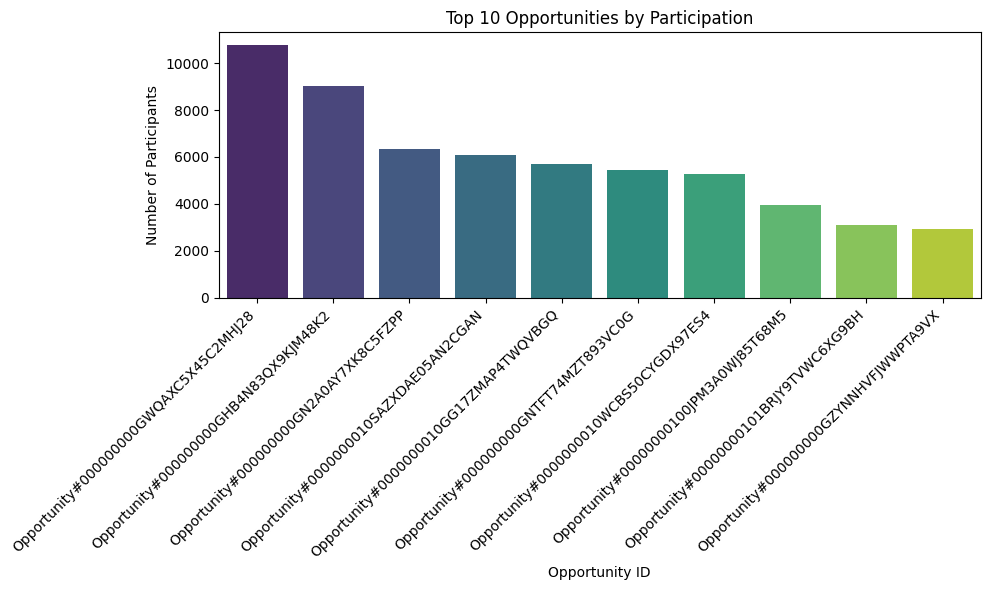

In [ ]:
# Top 10 Opportunities by Participation
if "learner_id" in learner_df.columns:
    top_opps = learner_df["learner_id"].value_counts().head(10).reset_index()
    top_opps.columns = ["opportunity_id", "count"]

    plt.figure(figsize=(10, 6))
    sns.barplot(x="opportunity_id", y="count", data=top_opps, palette="viridis")
    plt.title("Top 10 Opportunities by Participation")
    plt.xlabel("Opportunity ID")
    plt.ylabel("Number of Participants")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


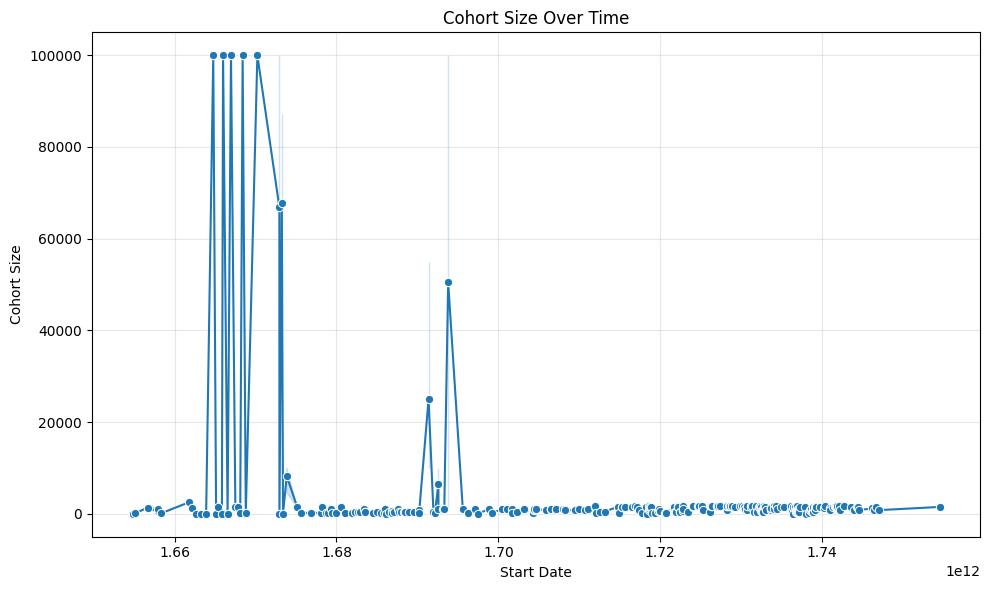

In [ ]:

# Cohort Size Over Time (Line Chart)
plt.figure(figsize=(10, 6))
sns.lineplot(x="start_date", y="size", data=cohort_df, marker="o")
plt.title("Cohort Size Over Time")
plt.xlabel("Start Date")
plt.ylabel("Cohort Size")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print(cohort_df.columns)


Index(['cohort_id', 'cohort_code', 'start_date', 'end_date', 'size'], dtype='object')


In [ ]:
print("Marketing DataFrame columns:")
print(marketing_df.columns.tolist())


Marketing DataFrame columns:
['Ad Account Name', 'Campaign name', 'Delivery status', 'Delivery level', 'Reach', 'Outbound clicks', 'Outbound type', 'Result type', 'Results', 'Cost per result', 'Amount spent (AED)', 'CPC (cost per link click)', 'dates']


/tmp/ipython-input-3980354992.py:15: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3980354992.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


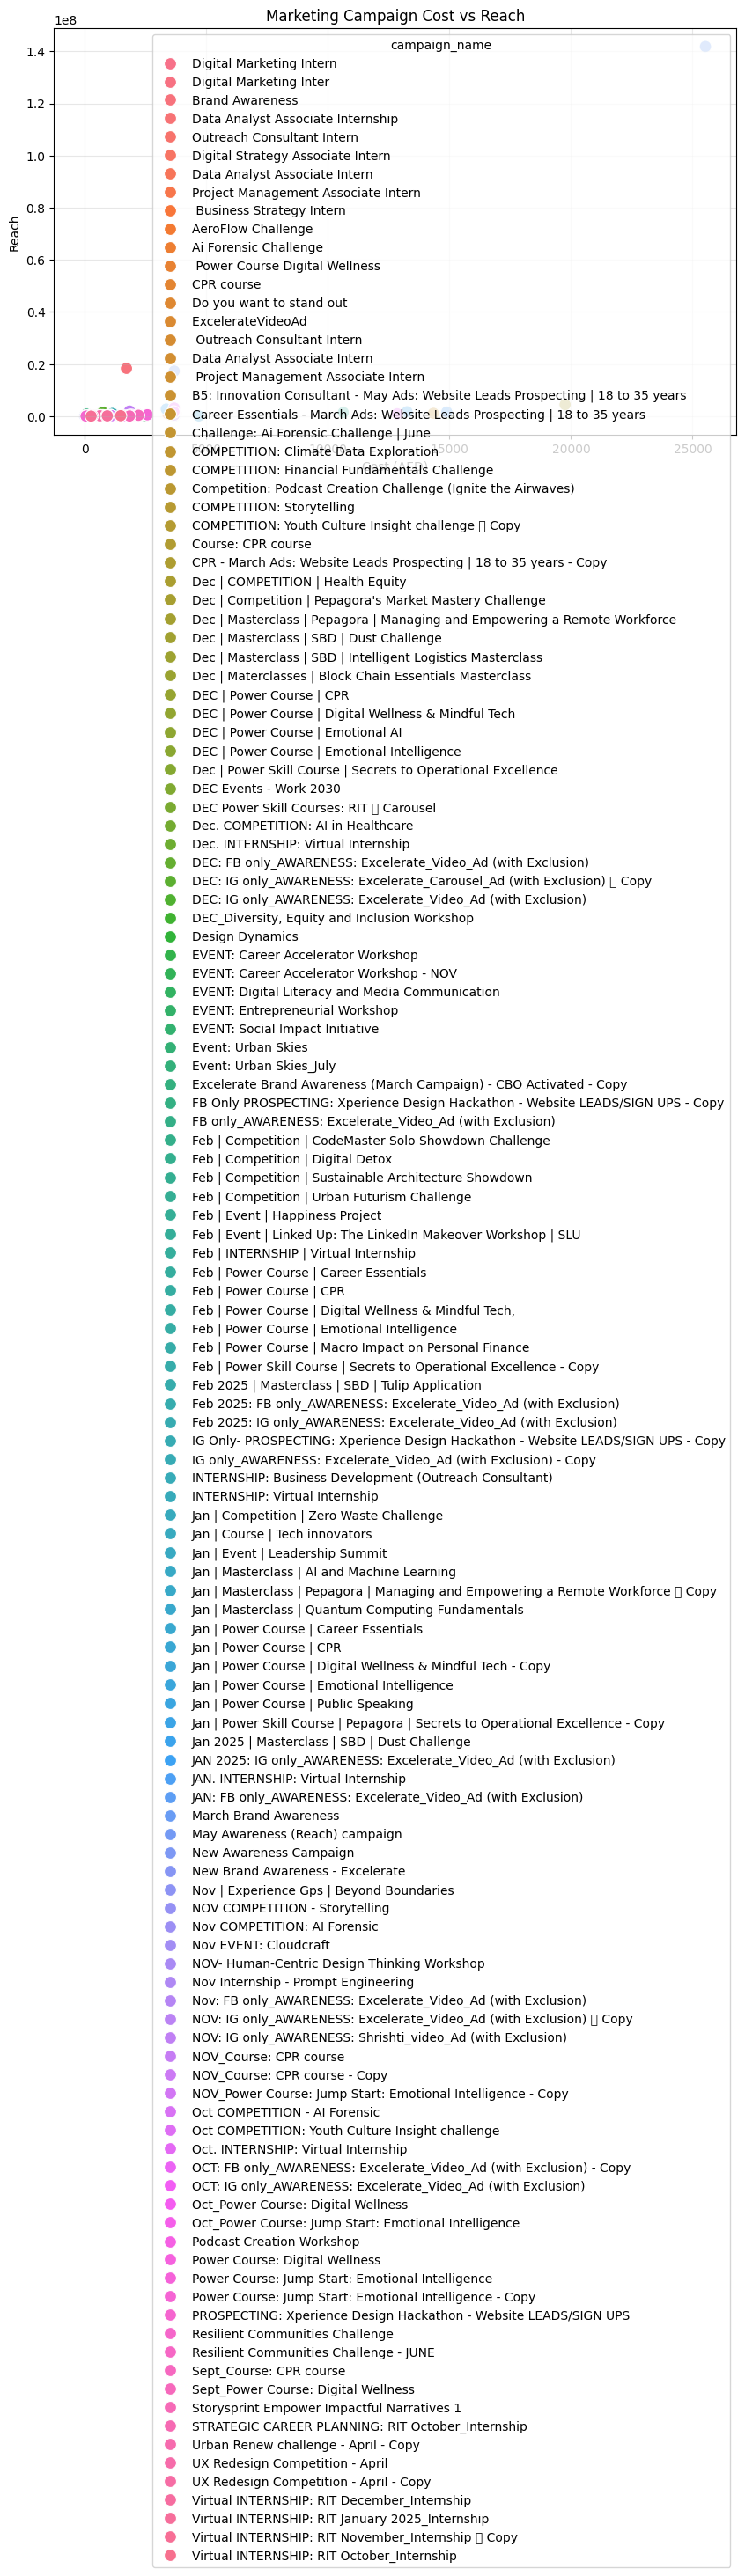

In [ ]:
# Rename columns for easier use
marketing_df.rename(columns={
    'Campaign name': 'campaign_name',
    'Amount spent (AED)': 'cost',
    'Reach': 'reach'
}, inplace=True)

# Scatter plot: Cost vs Reach
plt.figure(figsize=(10,6))
sns.scatterplot(x="cost", y="reach", data=marketing_df, hue="campaign_name", s=100)
plt.title("Marketing Campaign Cost vs Reach")
plt.xlabel("Cost (AED)")
plt.ylabel("Reach")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

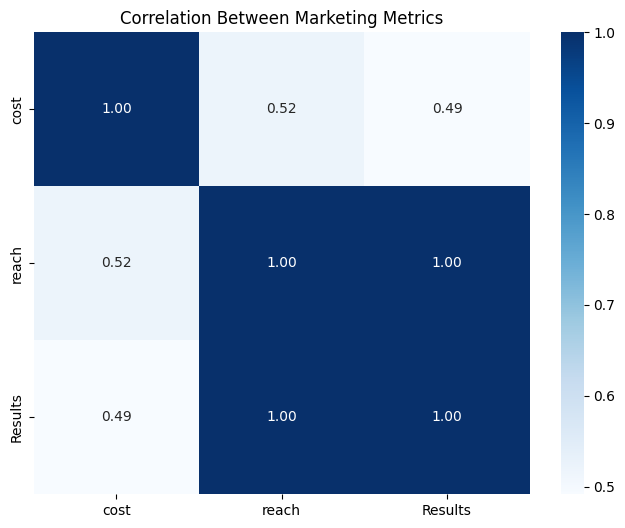

In [ ]:
# Correlation heatmap for numerical marketing metrics
plt.figure(figsize=(8,6))
corr = marketing_df[['cost', 'reach', 'Results']].corr()
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Between Marketing Metrics")
plt.show()

In [ ]:
cleaned_datasets = {}

for name, df in datasets.items():
    df = df.drop_duplicates()  # Remove duplicates
    df = df.apply(lambda x: x.fillna("Unknown") if x.dtype == "object" else x.fillna(x.median()))

    # Convert date columns automatically
    for col in df.columns:
        if "date" in col.lower():
            df[col] = pd.to_datetime(df[col], errors="coerce")

    cleaned_datasets[name] = df
    df.to_csv(f"{name.replace(' ', '_').lower()}_clean.csv", index=False)
    print(f"✅ Cleaned {name} saved as {name.replace(' ', '_').lower()}_clean.csv")


✅ Cleaned User Data saved as user_data_clean.csv
✅ Cleaned Opportunity Data saved as opportunity_data_clean.csv
✅ Cleaned Cohort Data saved as cohort_data_clean.csv
✅ Cleaned Marketing Data saved as marketing_data_clean.csv


/tmp/ipython-input-3922582842.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")


✅ Cleaned Learner Opportunity saved as learner_opportunity_clean.csv
✅ Cleaned Cognito Data saved as cognito_data_clean.csv


In [ ]:
for name in cleaned_datasets.keys():
    files.download(f"{name.replace(' ', '_').lower()}_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 2️⃣ Transform
# ========================

cleaned_data = {}
for name, df in datasets.items():
    print(f"\n🧹 Cleaning {name} ...")

    # Remove duplicates
    df = df.drop_duplicates()

    # Handle missing values
    for col in df.columns:
        if df[col].dtype == 'O':
            df[col] = df[col].fillna("Unknown")
        else:
            df[col] = df[col].fillna(df[col].median())


🧹 Cleaning User Data ...

🧹 Cleaning Opportunity Data ...

🧹 Cleaning Cohort Data ...

🧹 Cleaning Marketing Data ...

🧹 Cleaning Learner Opportunity ...


/tmp/ipython-input-666495809.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna("Unknown")
/tmp/ipython-input-666495809.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna(df[col].median())



🧹 Cleaning Cognito Data ...


In [ ]:
import pandas as pd

# Load the CSV files
user_df = pd.read_csv("Learner_Raw(in).csv")
opportunity_df = pd.read_csv("Opportunity_Raw(in).csv")
cohort_df = pd.read_csv("CohortRaw(in).csv")
learner_opportunity_df = pd.read_csv("LearnerOpportunity_Raw(in).csv")
cognito_df = pd.read_csv("Cognito_Raw2(in).csv")
marketing_df = pd.read_csv("Marketing Campaign Data All Accounts (2023-2024)(Detail1).csv", encoding='latin-1')


# Print the columns of each DataFrame
print("User DataFrame columns:")
print(user_df.columns.tolist())

print("\nOpportunity DataFrame columns:")
print(opportunity_df.columns.tolist())

print("\nCohort DataFrame columns:")
print(cohort_df.columns.tolist())

print("\nLearner Opportunity DataFrame columns:")
print(learner_opportunity_df.columns.tolist())

print("\nCognito DataFrame columns:")
print(cognito_df.columns.tolist())

print("\nMarketing DataFrame columns:")
print(marketing_df.columns.tolist())

User DataFrame columns:
['learner_id', 'country', 'degree', 'institution', 'major']

Opportunity DataFrame columns:
['opportunity_id', 'opportunity_name', 'category', 'opportunity_code', 'tracking_questions']

Cohort DataFrame columns:
['cohort_id', 'cohort_code', 'start_date', 'end_date', 'size']

Learner Opportunity DataFrame columns:
['enrollment_id', 'learner_id', 'assigned_cohort', 'apply_date', 'status']

Cognito DataFrame columns:
['user_id', 'email', 'gender', 'UserCreateDate', 'UserLastModifiedDate', 'birthdate', 'city', 'zip', 'state']

Marketing DataFrame columns:
['Ad Account Name', 'Campaign name', 'Delivery status', 'Delivery level', 'Reach', 'Outbound clicks', 'Outbound type', 'Result type', 'Results', 'Cost per result', 'Amount spent (AED)', 'CPC (cost per link click)', 'dates']


In [ ]:
import pandas as pd
# 1. EXTRACT
user_df = pd.read_csv("Learner_Raw(in).csv")
opportunity_df = pd.read_csv("Opportunity_Raw(in).csv")
cohort_df = pd.read_csv("CohortRaw(in).csv")
learner_opp_df = pd.read_csv("LearnerOpportunity_Raw(in).csv")
cognito_df = pd.read_csv("Cognito_Raw2(in).csv")
marketing_df = pd.read_csv("Marketing Campaign Data All Accounts (2023-2024)(Detail1).csv", encoding='latin-1')

In [ ]:
# 2. TRANSFORM
# --- Standardize column names ---
def clean_columns(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    return df

user_df = clean_columns(user_df)
opportunity_df = clean_columns(opportunity_df)
cohort_df = clean_columns(cohort_df)
learner_opp_df = clean_columns(learner_opp_df)
cognito_df = clean_columns(cognito_df)
marketing_df = clean_columns(marketing_df)

In [ ]:
# --- Handle missing values ---
user_df = user_df.fillna("Unknown")
opportunity_df = opportunity_df.fillna("Unknown")
cohort_df = cohort_df.fillna("Unknown")
learner_opp_df = learner_opp_df.fillna("Unknown")
cognito_df = cognito_df.fillna("Unknown")
marketing_df = marketing_df.fillna("Unknown")

In [ ]:
# --- Remove duplicates ---
user_df = user_df.drop_duplicates()
opportunity_df = opportunity_df.drop_duplicates()
cohort_df = cohort_df.drop_duplicates()
learner_opp_df = learner_opp_df.drop_duplicates()
cognito_df = cognito_df.drop_duplicates()
marketing_df = marketing_df.drop_duplicates()

In [ ]:
# ========================
# 3. LOAD (Create Master Table)
# ========================

# Merge step-by-step based on known relationships:
# learner_opp_df.learner_id ↔ users_df.learner_id
# learner_opp_df.assigned_cohort ↔ cohort_df.cohort_code
# learner_opp_df.learner_id ↔ cognito_df.user_id (if mapping is correct)

master_df = learner_opp_df.merge(user_df, on="learner_id", how="left")
master_df = master_df.merge(cohort_df, left_on="assigned_cohort", right_on="cohort_code", how="left")
master_df = master_df.merge(cognito_df, left_on="learner_id", right_on="user_id", how="left")

In [ ]:
import pandas as pd

# 1️⃣ Copy learner_opportunity
lo_df = learner_opportunity_df.copy()

# 2️⃣ Rename 'learner_id' to 'opportunity_id' (correct meaning)
lo_df = lo_df.rename(columns={'learner_id': 'opportunity_id'})

# 3️⃣ Join with opportunity data
lo_df = lo_df.merge(opportunity_df, on='opportunity_id', how='left')

# 4️⃣ Join with user data (true learner_id comes from enrollment_id)
lo_df = lo_df.merge(users_df, left_on='enrollment_id', right_on='learner_id', how='left', suffixes=('', '_user'))

# 5️⃣ Prepare for Cognito join: strip "Learner#" from learner_id
lo_df['learner_uuid'] = lo_df['learner_id'].str.replace('Learner#', '', regex=False)

# Also prepare Cognito user_id
cognito_df['user_id'] = cognito_df['user_id'].astype(str)

# 6️⃣ Join with Cognito data
lo_df = lo_df.merge(cognito_df, left_on='learner_uuid', right_on='user_id', how='left', suffixes=('', '_cognito'))

# 7️⃣ Join with Cohort data
lo_df = lo_df.merge(cohort_df, left_on='assigned_cohort', right_on='cohort_code', how='left')

# 8️⃣ Final master table selection
master_table = lo_df[[
    'enrollment_id',
    'learner_id',  # from users_df
    'country', 'degree', 'institution', 'major',
    'user_id', 'email', 'gender', 'birthdate', 'city', 'zip', 'state',
    'opportunity_id', 'opportunity_name', 'category', 'opportunity_code',
    'assigned_cohort', 'cohort_id', 'size', 'apply_date', 'status'
]]

print(master_table.head())


NameError: name 'users_df' is not defined

In [ ]:
import pandas as pd

# 1️⃣ Copy learner_opportunity
lo_df = learner_opportunity_df.copy()

# 2️⃣ Rename 'learner_id' to 'opportunity_id' (correct meaning)
lo_df = lo_df.rename(columns={'learner_id': 'opportunity_id'})

# 3️⃣ Join with opportunity data
lo_df = lo_df.merge(opportunity_df, on='opportunity_id', how='left')

# 4️⃣ Join with user data (true learner_id comes from enrollment_id)
lo_df = lo_df.merge(user_df, left_on='enrollment_id', right_on='learner_id', how='left', suffixes=('', '_user'))

# 5️⃣ Prepare for Cognito join: strip "Learner#" from learner_id
lo_df['learner_uuid'] = lo_df['learner_id'].str.replace('Learner#', '', regex=False)

# Also prepare Cognito user_id
cognito_df['user_id'] = cognito_df['user_id'].astype(str)

# 6️⃣ Join with Cognito data
lo_df = lo_df.merge(cognito_df, left_on='learner_uuid', right_on='user_id', how='left', suffixes=('', '_cognito'))

# 7️⃣ Join with Cohort data
lo_df = lo_df.merge(cohort_df, left_on='assigned_cohort', right_on='cohort_code', how='left')

# 8️⃣ Final master table selection
master_table = lo_df[[
    'enrollment_id',
    'learner_id',  # from users_df
    'country', 'degree', 'institution', 'major',
    'user_id', 'email', 'gender', 'birthdate', 'city', 'zip', 'state',
    'opportunity_id', 'opportunity_name', 'category', 'opportunity_code',
    'assigned_cohort', 'cohort_id', 'size', 'apply_date', 'status'
]]

print(master_table.head())

                                  enrollment_id  \
0  Learner#4e6f78a9-f9b2-4352-ad22-d43dc46f5ff7   
1  Learner#4e79d245-3436-4fec-9906-901a03639ad1   
2  Learner#4e9f5cb5-0576-4dbc-b7f5-1fae5f29b2df   
3  Learner#4ea61aa9-17da-4b60-9872-359b8e1e1635   
4  Learner#4eb218c7-467a-470a-9e3e-a2b7bc649e18   

                                     learner_id        country  \
0  Learner#4e6f78a9-f9b2-4352-ad22-d43dc46f5ff7          India   
1  Learner#4e79d245-3436-4fec-9906-901a03639ad1  United States   
2  Learner#4e9f5cb5-0576-4dbc-b7f5-1fae5f29b2df          Ghana   
3  Learner#4ea61aa9-17da-4b60-9872-359b8e1e1635          Ghana   
4  Learner#4eb218c7-467a-470a-9e3e-a2b7bc649e18       Pakistan   

                  degree                                        institution  \
0  Undergraduate Student                     Dr Br Ambedkar Medical College   
1       Graduate Student                             saint louis university   
2    High School Student  Community Development Vocational 

In [ ]:
# 2. Check for missing critical fields
missing_summary = master_df.isnull().sum()
print("\nMissing values in each column:")
print(missing_summary[missing_summary > 0])



Missing values in each column:
country                 113602
degree                  113602
institution             113602
major                   113602
cohort_id                13318
cohort_code              13318
start_date               13318
end_date                 13318
size                     13318
user_id                 113602
email                   113602
gender                  113602
usercreatedate          113602
userlastmodifieddate    113602
birthdate               113602
city                    113602
zip                     113602
state                   113602
dtype: int64


In [ ]:
# 1️⃣ Clean IDs for better joins
learner['learner_id_clean'] = learner['learner_id'].str.replace('Learner#', '', regex=False).str.strip().str.lower()
cognito['user_id_clean'] = cognito['user_id'].str.strip().str.lower()

learner_opp['learner_id_clean'] = learner_opp['learner_id'].str.replace('Learner#', '', regex=False).str.strip().str.lower()
learner_opp['assigned_cohort_clean'] = learner_opp['assigned_cohort'].str.strip().str.lower()

cohort['cohort_code_clean'] = cohort['cohort_code'].str.strip().str.lower()


In [ ]:
# Export master table
master_table.to_csv("master_table.csv", index=False)
print("✅ Master Table saved successfully")


NameError: name 'master_table' is not defined

In [ ]:
import pandas as pd

# 1️⃣ Copy learner_opportunity
lo_df = learner_opportunity_df.copy()

# 2️⃣ Rename 'learner_id' to 'opportunity_id' (correct meaning)
lo_df = lo_df.rename(columns={'learner_id': 'opportunity_id'})

# 3️⃣ Join with opportunity data
lo_df = lo_df.merge(opportunity_df, on='opportunity_id', how='left')

# 4️⃣ Join with user data (true learner_id comes from enrollment_id)
lo_df = lo_df.merge(user_df, left_on='enrollment_id', right_on='learner_id', how='left', suffixes=('', '_user'))

# 5️⃣ Prepare for Cognito join: strip "Learner#" from learner_id
lo_df['learner_uuid'] = lo_df['learner_id'].str.replace('Learner#', '', regex=False)

# Also prepare Cognito user_id
cognito_df['user_id'] = cognito_df['user_id'].astype(str)

# 6️⃣ Join with Cognito data
lo_df = lo_df.merge(cognito_df, left_on='learner_uuid', right_on='user_id', how='left', suffixes=('', '_cognito'))

# 7️⃣ Join with Cohort data
lo_df = lo_df.merge(cohort_df, left_on='assigned_cohort', right_on='cohort_code', how='left')

# 8️⃣ Final master table selection
master_table = lo_df[[
    'enrollment_id',
    'learner_id',  # from users_df
    'country', 'degree', 'institution', 'major',
    'user_id', 'email', 'gender', 'birthdate', 'city', 'zip', 'state',
    'opportunity_id', 'opportunity_name', 'category', 'opportunity_code',
    'assigned_cohort', 'cohort_id', 'size', 'apply_date', 'status'
]]

print(master_table.head())

NameError: name 'learner_opportunity_df' is not defined

In [ ]:
# Export master table
master_table.to_csv("master_table.csv", index=False)
print("✅ Master Table saved successfully")

NameError: name 'master_table' is not defined